In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)


In [2]:
train = pd.read_csv('train_final.csv')

In [3]:
test = pd.read_csv('test_final.csv')

In [4]:
import numpy as np

SEQ_LEN = 12

features = [
'voltage_mean',
'voltage_std',
'voltage_max',
'voltage_min',
'temperature_mean',
'temperature_max',
'capacity',
'capacity_fade',
'cycle_number'
]

target = 'SOH'


def create_sequences(df):

    X = []
    y = []

    for cell in df['cell_id'].unique():

        cell_data = df[df['cell_id'] == cell]

        X_cell = cell_data[features].values
        y_cell = cell_data[target].values

        for i in range(len(cell_data) - SEQ_LEN):

            X.append(X_cell[i:i+SEQ_LEN])
            y.append(y_cell[i+SEQ_LEN])

    return np.array(X), np.array(y)

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

In [6]:
X_train, y_train = create_sequences(train)

X_test, y_test = create_sequences(test)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam

def build_model():
    model = Sequential()

    model.add(Input(shape=(SEQ_LEN, len(features))))

    model.add(LSTM(64, return_sequences=True))

    model.add(GRU(32))

    model.add(Dense(32, activation='relu'))

    model.add(Dense(16, activation='relu'))


    model.add(Dense(1))
    
    model.compile(
    optimizer=Adam(learning_rate = 0.0005),
    loss='mse',
    metrics=['mae']
    )
    return model

In [8]:
model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 12, 64)              │          18,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,953 (117.00 KB)

 Trainable params: 29,953 (117.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate = 0.0005),
    loss='mse',
    metrics=['mae']
)

In [10]:
models = []
predictions = []

N_MODELS = 3

for i in range(N_MODELS):
    print(f"Training model {i+1}/{N_MODELS}")

    model = build_model()

    model.fit(
        X_train, y_train,
        epochs=150,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    y_pred = model.predict(X_test)

    predictions.append(y_pred)
    models.append(model)

Training model 1/3
Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.9019 - mae: 0.9424 - val_loss: 0.5662 - val_mae: 0.7517
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4258 - mae: 0.6478 - val_loss: 0.2693 - val_mae: 0.5176
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1618 - mae: 0.3911 - val_loss: 0.0447 - val_mae: 0.2082
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0143 - mae: 0.0980 - val_loss: 0.0137 - val_mae: 0.1104
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0240 - mae: 0.1464 - val_loss: 0.0110 - val_mae: 0.0983
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0061 - mae: 0.0653 - val_loss: 0.0025 - val_mae: 0.0397
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0041 - mae: 0.0499 - val_loss: 0.0051 - val_mae: 0.0663
Epoch 8/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0033 - mae: 0.0445 - val_loss: 0.0012 - val_mae: 0.0249
Epoch 9/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - l

In [11]:
import numpy as np

predictions = np.array(predictions)

y_pred_ensemble = np.mean(predictions, axis=0)

In [12]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_ensemble)

print("Ensemble MAE:", mae)


Ensemble MAE: 0.005384209087247169


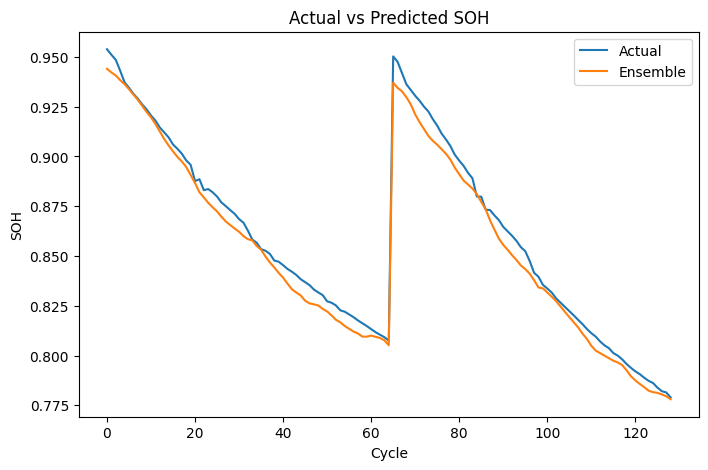

In [13]:
plt.figure(figsize=(8,5))

plt.plot(y_test, label="Actual")
plt.plot(y_pred_ensemble, label="Ensemble")

plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Actual vs Predicted SOH")

plt.legend()

plt.savefig("soh_prediction.png", dpi=300, bbox_inches='tight') 

plt.show()